# NFL Elimination Picks 2026

reqs:
```
pip install requests numpy scipy pandas matplotlib parsel
```

In [1]:
import datetime
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
#%load_ext autoreload
#%autoreload 2

In [3]:
import anysunday
import anysunday.powercalcs
from anysunday import viz, pick

In [ ]:
schedule = anysunday.loaders.espn_schedule("./schedules/2026.espn")

https://www.espn.com/nfl/fpi

In [5]:
powers = anysunday.loaders.espn_powers()
pd.DataFrame(powers.items()).T

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,KC,DET,BUF,PHI,GB,LAC,LAR,SF,DEN,WSH,...,ATL,LV,MIA,CLE,NYJ,CAR,NYG,NO,CIN,TEN
1,6.2,5.7,4.9,4.7,4.6,3.4,2.9,2.4,2.3,2.3,...,-2.0,-2.6,-3.4,-4.3,-4.6,-4.9,-6.0,-6.3,-6.5,-9.0


In [ ]:
picks = [
    "LAC", # week 1
    # "BAL", # week 2
    # "SEA", # week 3
    # "BUF", # week 4
    # "ARI", # week 5
]

(<Figure size 800x1000 with 2 Axes>,
 <Axes: xlabel='Week', ylabel='Pick to Win'>)

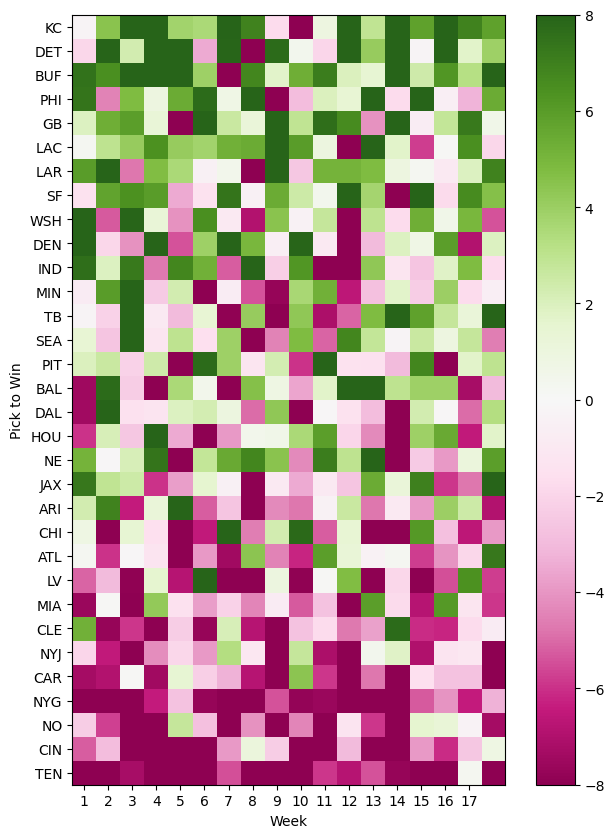

In [7]:
power_rank, matrix = anysunday.powercalcs.pick_grid(powers, schedule, home_bump=3)

viz.plot_matrix(matrix, power_rank)

In [8]:
tuned_home_bump = 3  # default is 3

ppkwargs = {
    "powers": powers,
    "schedule": schedule,
    "home_bump": tuned_home_bump,
    "past_picks": picks
}

In [9]:
pp = pick.Permuter(**ppkwargs)

pprev = pick.Permuter(**ppkwargs)
pprev.pick = pprev.reverse_greedy()

pprand = pick.Permuter(**ppkwargs)
pprand.pick = pprand.random_greedy()

pplg = pick.Permuter(**ppkwargs)
pplg.pick = pplg.limited_greedy(limit=8)

In [10]:
pp.describe_pick()

week  5: diff +11.0 - picking ARI (-1.0+H) over TEN (-9.0  )
week  6: diff +14.1 - picking GB  (+4.6+H) over CIN (-6.5  )
week  7: diff +11.8 - picking KC  (+6.2+H) over LV  (-2.6  )
week  8: diff +13.7 - picking PHI (+4.7+H) over NYG (-6.0  )
week  9: diff +12.2 - picking LAR (+2.9+H) over NO  (-6.3  )
week 10: diff  +7.8 - picking CHI (-1.2+H) over NYG (-6.0  )
week 11: diff  +9.9 - picking PIT (+0.4+H) over CIN (-6.5  )
week 12: diff +14.7 - picking DET (+5.7+H) over NYG (-6.0  )
week 13: diff  +9.0 - picking LAC (+3.4+H) over LV  (-2.6  )
week 14: diff +10.1 - picking TB  (+0.8+H) over NO  (-6.3  )
week 15: diff +14.4 - picking SF  (+2.4+H) over TEN (-9.0  )
week 16: diff  +6.1 - picking MIA (-3.4+H) over CIN (-6.5  )
week 17: diff  +6.4 - picking LV  (-2.6+H) over NYG (-6.0  )
week 18: diff +11.4 - picking JAX (-0.6+H) over TEN (-9.0  )


In [11]:
pprev.describe_pick()

week  5: diff +11.0 - picking ARI (-1.0+H) over TEN (-9.0  )
week  6: diff  +9.4 - picking LV  (-2.6+H) over TEN (-9.0  )
week  7: diff  +5.5 - picking NE  (-0.5  ) over TEN (-9.0+H)
week  8: diff +13.7 - picking PHI (+4.7+H) over NYG (-6.0  )
week  9: diff +12.2 - picking LAR (+2.9+H) over NO  (-6.3  )
week 10: diff  +7.8 - picking CHI (-1.2+H) over NYG (-6.0  )
week 11: diff  +9.9 - picking PIT (+0.4+H) over CIN (-6.5  )
week 12: diff +14.7 - picking DET (+5.7+H) over NYG (-6.0  )
week 13: diff  +9.0 - picking LAC (+3.4+H) over LV  (-2.6  )
week 14: diff +10.1 - picking TB  (+0.8+H) over NO  (-6.3  )
week 15: diff +14.4 - picking SF  (+2.4+H) over TEN (-9.0  )
week 16: diff +12.2 - picking KC  (+6.2  ) over TEN (-9.0+H)
week 17: diff  +7.2 - picking GB  (+4.6+H) over BAL (+0.4  )
week 18: diff +11.4 - picking JAX (-0.6+H) over TEN (-9.0  )


In [12]:
pprand.describe_pick()

week  5: diff +11.0 - picking ARI (-1.0+H) over TEN (-9.0  )
week  6: diff  +9.4 - picking LV  (-2.6+H) over TEN (-9.0  )
week  7: diff +11.8 - picking KC  (+6.2+H) over LV  (-2.6  )
week  8: diff +13.7 - picking PHI (+4.7+H) over NYG (-6.0  )
week  9: diff +12.5 - picking GB  (+4.6+H) over CAR (-4.9  )
week 10: diff  +7.8 - picking CHI (-1.2+H) over NYG (-6.0  )
week 11: diff  +9.9 - picking PIT (+0.4+H) over CIN (-6.5  )
week 12: diff +14.7 - picking DET (+5.7+H) over NYG (-6.0  )
week 13: diff  +9.0 - picking LAC (+3.4+H) over LV  (-2.6  )
week 14: diff +10.1 - picking TB  (+0.8+H) over NO  (-6.3  )
week 15: diff +14.4 - picking SF  (+2.4+H) over TEN (-9.0  )
week 16: diff  +6.1 - picking MIA (-3.4+H) over CIN (-6.5  )
week 17: diff  +5.0 - picking WSH (+2.3+H) over DAL (+0.3  )
week 18: diff +11.4 - picking JAX (-0.6+H) over TEN (-9.0  )


In [13]:
pplg.describe_pick()

week  5: diff  +9.2 - picking DET (+5.7  ) over CIN (-6.5+H)
week  6: diff  +9.4 - picking LV  (-2.6+H) over TEN (-9.0  )
week  7: diff  +8.1 - picking CHI (-1.2+H) over NO  (-6.3  )
week  8: diff +13.2 - picking IND (+1.2+H) over TEN (-9.0  )
week  9: diff  +9.4 - picking LAC (+3.4  ) over TEN (-9.0+H)
week 10: diff  +4.4 - picking CAR (-4.9+H) over NO  (-6.3  )
week 11: diff  +9.9 - picking PIT (+0.4+H) over CIN (-6.5  )
week 12: diff +10.3 - picking SF  (+2.4+H) over CAR (-4.9  )
week 13: diff  +8.5 - picking NE  (-0.5+H) over NYG (-6.0  )
week 14: diff  +8.8 - picking GB  (+4.6+H) over CHI (-1.2  )
week 15: diff +10.3 - picking PHI (+4.7+H) over LV  (-2.6  )
week 16: diff +12.2 - picking KC  (+6.2  ) over TEN (-9.0+H)
week 17: diff  +5.0 - picking WSH (+2.3+H) over DAL (+0.3  )
week 18: diff  +8.7 - picking TB  (+0.8+H) over CAR (-4.9  )
